The expected number of active points per unit length (assuming unit intensity of initial 2D PPP) is root(pi)/2 (Lemma 2.3 in https://arxiv.org/pdf/2209.09680)

In [19]:
#import exclusionprocess as ep
import numpy as np 


Samples=500 #Number of times you sample the point process
lam=1   #Intensity of points
L=100   #Finite length (x-axis) of exclusion area
H=100  #Finite height (y-axis) of exclusion area
v=1     #Replication fork speed, recommend keeping this as 1 all the time

In [20]:
def TDPPP(lam, L, H):
    """
    2-dimensional Poisson point process of rate lam
    :param lam: Gives the rate of the PPP
    :param L: length of segment
    :param H: height of segment
    :return:
    [0] - Returns a list of the locations of nodes for a 2D PPP
    [1] - no. of nodes
    """
    L = float(L)
    H = float(H)
    n_nodes = np.random.poisson(lam * L * H)  # Poisson number of points
    node_X = sorted(np.random.uniform(0, L, n_nodes))
    node_Y = np.random.uniform(0, H, n_nodes)
    return node_X, node_Y, n_nodes

In [21]:
def AlgoTwo(PPP, v):
    """
    This algorithm is a more efficient method to find the active points in a 2D Poisson point process.
    It uses a greedy approach to find the lowest point and checks if it is active.
    Loop through remaining active points
    For each procedural lowest active point, check if it is made passive by any of the active points below it
    If not it's active. Add it to the active list.
    Terminate when you run out of active points.
    :param PPP: A tuple containing the locations, times, and number of points in the PPP
    :param v: The speed of the replication fork in the exclusion process
    :return: A tuple containing the active points, number of active points, and total number of points
    """
    Locations, Times, N = PPP
    #Pulls out the number of nodes
    Locations = list(Locations) #Pulls out the locations
    Times = list(Times) #Generates the trigger times for each origin

    #Find the lowest point by y coordinate
    #Lowest point is active 
    y=min(Times)
    x=Locations[Times.index(y)]

    Times.remove(y)
    Locations.remove(x)

    Active = [] #This array will be filled with the active points
    AccTimes=[]

    Active.append(x)
    AccTimes.append(y)

    while len(Times)>0:
        y=min(Times)
        x=Locations[Times.index(y)]
        j=0
        ACount=0
        while j<len(Active):
            if AccTimes[j]<y-abs(Active[j]-x)/v:
                ACount+=1
                break
            j+=1
        if ACount==0:
            Active.append(x)
            AccTimes.append(y)
        #print(f"Counter ={ACount}")
        Times.remove(y)
        Locations.remove(x)
    
    NoActive2=len(Active) #Count the number of active points
    #Spacings2=[Active[i+1]-Active[i] for i in range(NoActive2-1)] 
    return Active, NoActive2, N


In [22]:
from tqdm import tqdm

AverageActive = []

for j in tqdm(range(Samples), desc="Processing samples"):
    #print(f"Sample {j+1}/{Samples}")
    PPP = TDPPP(lam, L, H)
    Active, NoActive, N = AlgoTwo(PPP, 1)
    
    if len(Active) > 0:
        assert len(Active) == NoActive
        ActiveNorm = NoActive / L
        AverageActive.append(ActiveNorm)

print(f"Total number of active points (normalized): {len(AverageActive)}")
print(AverageActive)

Processing samples: 100%|██████████| 500/500 [30:18<00:00,  3.64s/it]

Total number of active points (normalized): 500
[0.89, 0.91, 0.9, 0.85, 0.84, 0.81, 0.91, 0.95, 0.8, 0.88, 0.84, 0.88, 0.84, 0.87, 0.84, 0.84, 0.86, 0.78, 0.91, 0.9, 0.9, 0.95, 0.88, 0.85, 0.94, 0.95, 0.97, 0.83, 0.9, 0.93, 0.87, 1.01, 0.89, 0.96, 0.83, 0.88, 0.92, 0.91, 0.87, 0.96, 0.86, 0.86, 0.97, 0.96, 0.84, 0.88, 0.78, 0.88, 0.89, 0.93, 0.88, 0.93, 0.86, 0.91, 0.9, 0.85, 0.92, 0.86, 0.88, 0.83, 0.84, 0.82, 0.77, 0.85, 0.89, 0.88, 0.86, 0.89, 0.94, 0.94, 0.87, 0.89, 0.81, 0.84, 0.81, 0.96, 0.88, 0.97, 1.01, 0.96, 0.89, 0.91, 1.01, 0.92, 0.86, 0.9, 0.88, 0.87, 0.83, 1.0, 0.91, 0.95, 0.84, 0.94, 0.88, 0.95, 0.84, 0.92, 1.02, 0.87, 0.86, 0.97, 0.79, 0.95, 0.89, 0.88, 0.91, 1.05, 0.86, 0.92, 0.94, 0.87, 0.88, 0.85, 0.91, 0.93, 0.94, 0.84, 0.87, 0.85, 0.92, 0.83, 0.9, 0.91, 0.91, 0.73, 0.86, 0.94, 0.8, 0.94, 0.89, 0.94, 0.89, 0.84, 0.92, 0.95, 0.84, 0.91, 0.83, 0.98, 0.87, 0.85, 0.74, 0.8, 0.92, 0.91, 0.88, 0.95, 0.85, 0.84, 0.92, 0.88, 0.99, 0.92, 0.95, 0.89, 0.9, 0.85, 0.92, 0.84, 0.8

In [23]:
Value = np.sqrt(np.pi)/2
print(f"Theoretical Value (sqrt(pi)/2): {Value}")

Theoretical Value (sqrt(pi)/2): 0.8862269254527579


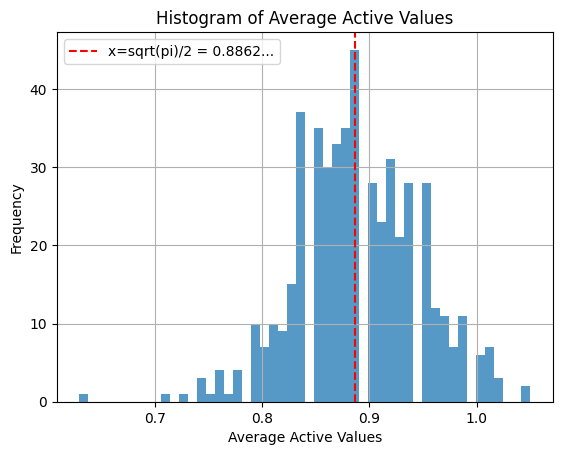

In [27]:
# Print a histogram of the conversion values
import matplotlib.pyplot as plt
plt.hist(AverageActive, bins=50, alpha=0.75)
plt.xlabel('Average Active Values')
plt.ylabel('Frequency')
plt.title('Histogram of Average Active Values')
plt.grid(True)
# Add a straight line at x=np.pi for reference
plt.axvline(x=Value, color='r', linestyle='--', label=f'x=sqrt(pi)/2 = {Value:.4f}...')
plt.legend()
plt.show()

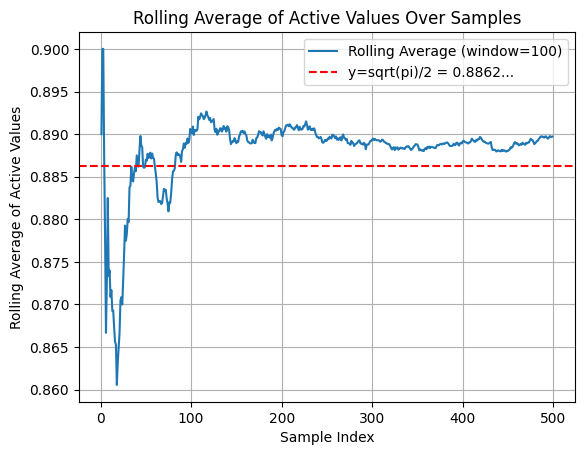

In [25]:
x = [i for i in range(len(AverageActive))]
rolling_avg = [np.mean(AverageActive[:i]) for i in range(len(AverageActive))]

plt.plot(x, rolling_avg, label='Rolling Average (window=100)')
plt.axhline(y=Value, color='r', linestyle='--', label=f'y=sqrt(pi)/2 = {Value:.4f}...')
plt.xlabel('Sample Index')
plt.ylabel('Rolling Average of Active Values')
plt.title('Rolling Average of Active Values Over Samples')
plt.legend()
plt.grid(True)
plt.show()